# Time Channel Data Smoothing

- Load and normalize the NE ATEM data.
- Bin each flight line at 50 m spacing.
- Map binned data by time channel in x-y space.
- Smooth the binned data with KDTree neighbors.
- Compare original and smoothed data with a normalized L2 norm.
- Extract locations where the normalized L2 norm is greater than 0.3.


In [1]:
import json
import dill

import numpy as np
import pandas as pd
from rich import print
from matplotlib import pyplot as plt
from matplotlib import rcParams as rc
from matplotlib.colors import LogNorm
from ipywidgets import widgets
from ipywidgets import VBox, HBox, interactive_output
from scipy.spatial import cKDTree as KDTree
from simpeg.electromagnetics.utils.em1d_utils import get_vertical_discretization

rc["font.family"] = "Times New Roman"
rc["font.size"] = 14
rc["figure.figsize"] = (6, 4)
rc["axes.grid"] = True


## Load Configuration

Select the time channels used in the previous inversion workflow.


In [2]:
istart_channel: int = 3
iend_channel: int = 25

conf = json.load(open("../../atem/data/atem.json"))
times = np.asarray(conf["channels"])[istart_channel:iend_channel] * 1e-6
n_turns = conf["n_turns"]

dheader = [f"zoff30[{i}]" for i in range(istart_channel, iend_channel)]
time_labels = [f"{name} / {time:.2e} s" for name, time in zip(dheader, times)]


## Load And Normalize Data

Read the NE survey data and apply the same normalization used in notebook 06.


In [3]:
area: str = "NE"
path: str = f"../../atem/data/11-024_Alberta_{area}.csv"
picker = [
    "Line",
    "bheight",
    "TranPeak",
    "x_wgs84",
    "y_wgs84",
    "flight",
    "pwrline",
    "dtm",
] + dheader

raws = pd.read_csv(path)[picker]
xy_raw = raws[["x_wgs84", "y_wgs84"]].to_numpy()
normalizer = (-1e-9) / (raws["TranPeak"].values * n_turns).reshape(-1, 1)
raws[dheader] = raws[dheader] * normalizer
line_no = list(raws["Line"].unique())


## Check Missing Coordinates

Identify flight lines with missing y coordinates before binning.


<StringArray>
['L10151', 'L10460', 'L10660', 'L10700']
Length: 4, dtype: str

[65, 1, 280, 1045]

/var/folders/2c/w5d04hwn6k56y8m_fmjdt1v40000gn/T/ipykernel_6126/797230168.py:20: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


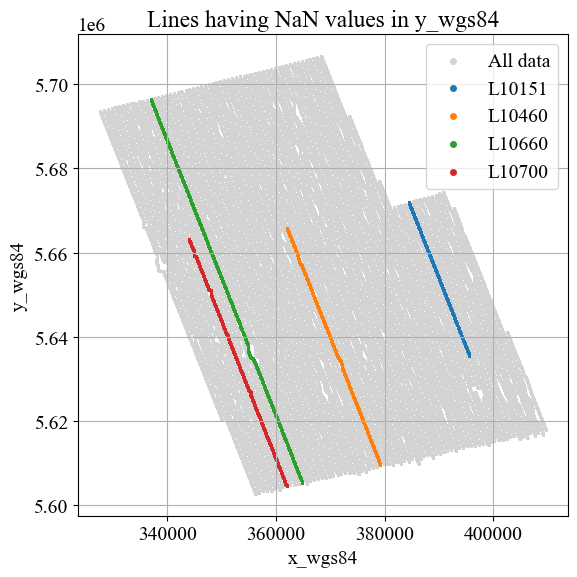

In [4]:
nan_list = raws[raws["y_wgs84"].isna()]["Line"].unique()
print(nan_list)

counts = []
for line_n in nan_list:
    count = raws[raws["Line"] == line_n]["y_wgs84"].isna().sum()
    counts.append(count)
print(counts)

plt.figure(figsize=(6, 6))
plt.scatter(xy_raw[:, 0], xy_raw[:, 1], s=1, c="lightgray", label="All data")
for i, line_n in enumerate(nan_list):
    test_x = raws[raws["Line"] == line_n]["x_wgs84"]
    test_y = raws[raws["Line"] == line_n]["y_wgs84"]
    plt.scatter(test_x, test_y, s=1, c=f"C{i}", label=line_n)
plt.xlabel("x_wgs84")
plt.ylabel("y_wgs84")
plt.title("Lines having NaN values in y_wgs84")
plt.legend(markerscale=4)
plt.tight_layout()


## Clean And Bin Data

Remove missing y coordinates and bin each line at 50 m spacing.


In [5]:
raws.dropna(subset=["y_wgs84"], inplace=True)
raws.fillna(1e-20, inplace=True)

dx = 50.0
values = []
values_std = []
soundings = []
istart = 0
iend = len(line_no)

for i_line, line in enumerate(line_no[istart:iend]):
    df_line = raws[raws["Line"] == line].copy()

    xy_line = df_line[["x_wgs84", "y_wgs84"]].to_numpy()
    distance = np.sqrt(((xy_line - xy_line[0, :]) ** 2).sum(axis=1))
    max_distance = distance.max()

    if max_distance % dx == 0:
        n_sounding = int(max_distance / dx)
    else:
        n_sounding = int(np.round(max_distance / dx) + 1)

    bins = np.arange(n_sounding) * dx
    df_line.insert(0, "distance", distance)
    df_line["bin"] = pd.cut(df_line["distance"], bins=bins)

    binned = (
        df_line.groupby("bin", observed=False)
        [["distance"] + picker[1:]]
        .mean()
    )
    binned.insert(0, "Line", line)

    binned_std = (
        df_line.groupby("bin", observed=False)
        [["bheight"] + dheader]
        .std()
    )

    values.append(binned.values)
    values_std.append(binned_std.values)
    soundings.append(n_sounding)

df_data_binned = pd.DataFrame(
    data=np.vstack(values),
    columns=["Line", "distance"] + picker[1:],
)
df_data_std_binned = pd.DataFrame(
    data=np.vstack(values_std),
    columns=["bheight"] + dheader,
)

valid_xy = np.isfinite(df_data_binned[["x_wgs84", "y_wgs84"]].values.astype(float)).all(axis=1)
if not valid_xy.all():
    print(f"Dropping {(~valid_xy).sum():,} empty binned rows before mapping.")
    df_data_binned = df_data_binned.loc[valid_xy].reset_index(drop=True)
    df_data_std_binned = df_data_std_binned.loc[valid_xy].reset_index(drop=True)

xy_binned = df_data_binned[["x_wgs84", "y_wgs84"]].values.astype(float)
data_binned = df_data_binned[dheader].values.astype(float)
data_to_plot = -data_binned
plot_skip = 5
plot_indices = np.arange(0, xy_binned.shape[0], plot_skip)

print(f"Binned soundings: {len(df_data_binned):,}")
print(f"Time channels: {data_binned.shape[1]}")
print(f"Plotting every {plot_skip} sounding(s): {len(plot_indices):,} points")


Binned soundings: 134,101

Time channels: 22

Plotting every 5 sounding(s): 26,821 points

## Data Reliability Weights

Estimate channel-wise uncertainty from bin statistics and use reliable data more strongly during smoothing.


In [6]:
relative_error_cutoff = 0.03
minimum_relative_uncertainty = 0.05
floor_fraction = 0.05
noise_floor = 5e-9 / (df_data_binned["TranPeak"].values.astype(float) * n_turns) * floor_fraction

data_std_binned = df_data_std_binned[dheader].values.astype(float)
data_rerr = np.divide(
    data_std_binned,
    np.abs(data_binned),
    out=np.full_like(data_std_binned, np.inf, dtype=float),
    where=np.abs(data_binned) > 0,
)
bad_data_mask = data_rerr > relative_error_cutoff

base_uncertainty = np.maximum(data_std_binned, np.abs(data_binned) * minimum_relative_uncertainty)
data_uncertainty = base_uncertainty + noise_floor[:, None]
data_uncertainty[bad_data_mask] = np.inf

data_reliability_weight = np.divide(
    1.0,
    data_uncertainty**2,
    out=np.zeros_like(data_uncertainty, dtype=float),
    where=np.isfinite(data_uncertainty) & (data_uncertainty > 0),
)

active_data_fraction = np.isfinite(data_uncertainty).mean()
print(f"Active data fraction: {active_data_fraction * 100:.1f}%")
print(f"Bad data fraction: {bad_data_mask.mean() * 100:.1f}%")

pd.DataFrame(
    {
        "channel": dheader,
        "time_s": times,
        "active_fraction": np.isfinite(data_uncertainty).mean(axis=0),
        "median_relative_error": np.nanmedian(data_rerr, axis=0),
    }
)


Active data fraction: 84.8%

Bad data fraction: 15.2%

,channel,time_s,active_fraction,median_relative_error
0,zoff30[3],0.000188,0.899359,0.010714
1,zoff30[4],0.000230,0.909031,0.010236
2,zoff30[5],0.000286,0.917286,0.009845
3,zoff30[6],0.000341,0.922357,0.009551
4,zoff30[7],0.000397,0.925019,0.009346
5,zoff30[8],0.000452,0.926317,0.009220
6,zoff30[9],0.000508,0.925720,0.009178
7,zoff30[10],0.000563,0.924788,0.009152
8,zoff30[11],0.000619,0.923073,0.009152
9,zoff30[12],0.000688,0.921388,0.009230


## Original Time-Channel Map

Display the binned data in x-y space for a selected time channel.


In [7]:
def get_channel_limits(values, i_time, lower=2, upper=98):
    channel_values = values[:, i_time]
    finite = np.isfinite(channel_values)
    if not finite.any():
        return None, None
    return np.nanpercentile(channel_values[finite], [lower, upper])


map_line_options = [str(line) for line in pd.unique(df_data_binned["Line"])]


def plot_original_time_channel(i_channel, line_name):
    i_time = i_channel - istart_channel
    vmin, vmax = get_channel_limits(data_to_plot, i_time)
    line_mask = df_data_binned["Line"].astype(str).values == str(line_name)
    background_indices = plot_indices[~line_mask[plot_indices]]

    fig, ax = plt.subplots(1, 1, figsize=(7, 7))
    out = ax.scatter(
        xy_binned[background_indices, 0],
        xy_binned[background_indices, 1],
        c=data_to_plot[background_indices, i_time],
        s=1,
        cmap="turbo",
        vmin=vmin,
        vmax=vmax,
        edgecolors="none",
    )
    ax.scatter(
        xy_binned[line_mask, 0],
        xy_binned[line_mask, 1],
        c=data_to_plot[line_mask, i_time],
        s=12,
        cmap="turbo",
        vmin=vmin,
        vmax=vmax,
        linewidths=0.15,
    )
    colorbar_mappable = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=vmin, vmax=vmax), cmap="turbo")
    colorbar_mappable.set_array([])
    cb = plt.colorbar(colorbar_mappable, ax=ax, orientation="horizontal", fraction=0.05, pad=0.08)
    cb.set_label("-dB/dt")
    ax.set_xlabel("x_wgs84")
    ax.set_ylabel("y_wgs84")
    ax.set_aspect(1)
    ax.set_title(f"Original data: {time_labels[i_time]}, Line {line_name}")
    plt.tight_layout()
    plt.show()

original_time_slider = widgets.IntSlider(
    min=istart_channel,
    max=iend_channel - 1,
    step=1,
    value=istart_channel,
    description="zoff30:",
    continuous_update=False,
)
original_line_slider = widgets.SelectionSlider(
    options=map_line_options,
    value=map_line_options[0],
    description="Line:",
    continuous_update=False,
)
original_output = interactive_output(
    plot_original_time_channel,
    {"i_channel": original_time_slider, "line_name": original_line_slider},
)

VBox([original_time_slider, original_line_slider, original_output])


## KDTree Smoothing

Smooth each sounding with nearby soundings using a weak distance-weighted average.
- idw_power : $1/(distance + epsilon)^{power}$


In [8]:
# Smaller k and larger IDW power make the smoothing weaker.
k_nearest_points = 50
idw_epsilon = 1
idw_power_early = 1.5
idw_power_late = 2.0
idw_power_by_time = np.linspace(idw_power_early, idw_power_late, data_binned.shape[1])
# idw_power_by_time = np.full(data_binned.shape[1], 0.0)

n_neighbors = min(k_nearest_points, xy_binned.shape[0])
smoothing_chunk_size = 50_000
tree = KDTree(xy_binned)
smoothed_data = np.empty_like(data_binned)

for start in range(0, xy_binned.shape[0], smoothing_chunk_size):
    end = min(start + smoothing_chunk_size, xy_binned.shape[0])
    distances, neighbor_indices = tree.query(xy_binned[start:end], k=n_neighbors)

    if n_neighbors == 1:
        distances = distances[:, None]
        neighbor_indices = neighbor_indices[:, None]

    spatial_weights_by_time = 1.0 / ((distances[:, :, None] + idw_epsilon) ** idw_power_by_time[None, None, :])
    reliability_weights = data_reliability_weight[neighbor_indices, :]
    total_weights = spatial_weights_by_time * reliability_weights
    weight_sum = np.sum(total_weights, axis=1)
    weighted_sum = np.sum(total_weights * data_binned[neighbor_indices, :], axis=1)
    smoothed_data[start:end] = np.divide(
        weighted_sum,
        weight_sum,
        out=np.full_like(weighted_sum, np.nan, dtype=float),
        where=weight_sum > 0,
    )

smoothed_data_to_plot = -smoothed_data

print(f"KDTree neighbors: {n_neighbors}")
print(f"IDW epsilon: {idw_epsilon}")
print(f"IDW power range: {idw_power_by_time[0]:.2f} to {idw_power_by_time[-1]:.2f}")
print("Smoothing weights: spatial IDW x inverse-variance data reliability")
print(f"Smoothing chunk size: {smoothing_chunk_size:,}")

pd.DataFrame(
    {
        "channel": dheader,
        "time_s": times,
        "idw_power": idw_power_by_time,
    }
)


KDTree neighbors: 50

IDW epsilon: 1

IDW power range: 1.50 to 2.00

Smoothing weights: spatial IDW x inverse-variance data reliability

Smoothing chunk size: 50,000

,channel,time_s,idw_power
0,zoff30[3],0.000188,1.500000
1,zoff30[4],0.000230,1.523810
2,zoff30[5],0.000286,1.547619
3,zoff30[6],0.000341,1.571429
4,zoff30[7],0.000397,1.595238
5,zoff30[8],0.000452,1.619048
6,zoff30[9],0.000508,1.642857
7,zoff30[10],0.000563,1.666667
8,zoff30[11],0.000619,1.690476
9,zoff30[12],0.000688,1.714286


## Original And Smoothed Slices

Compare original and smoothed maps by time channel.


In [9]:
def plot_time_channel_comparison(i_channel, line_name):
    i_time = i_channel - istart_channel
    values_pair = np.r_[data_to_plot[:, i_time], smoothed_data_to_plot[:, i_time]]
    finite = np.isfinite(values_pair)
    vmin, vmax = np.nanpercentile(values_pair[finite], [2, 98])
    line_mask = df_data_binned["Line"].astype(str).values == str(line_name)
    background_indices = plot_indices[~line_mask[plot_indices]]

    fig, axs = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
    titles = ["Original", "KDTree smoothed"]
    arrays = [data_to_plot[:, i_time], smoothed_data_to_plot[:, i_time]]

    for ax, title, values_i in zip(axs, titles, arrays):
        out = ax.scatter(
            xy_binned[background_indices, 0],
            xy_binned[background_indices, 1],
            c=values_i[background_indices],
            s=1,
            cmap="turbo",
            vmin=vmin,
            vmax=vmax,
            edgecolors="none",
        )
        ax.scatter(
            xy_binned[line_mask, 0],
            xy_binned[line_mask, 1],
            c=values_i[line_mask],
            s=12,
            cmap="turbo",
            vmin=vmin,
            vmax=vmax,
            linewidths=0.15,
        )
        ax.set_xlabel("x_wgs84")
        ax.set_ylabel("y_wgs84")
        ax.set_aspect(1)
        ax.set_title(f"{title}: {time_labels[i_time]}, Line {line_name}")

    colorbar_mappable = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=vmin, vmax=vmax), cmap="turbo")
    colorbar_mappable.set_array([])
    cb = fig.colorbar(colorbar_mappable, ax=axs, orientation="horizontal", fraction=0.05, pad=0.08)
    cb.set_label("dB/dt")
    plt.show()

comparison_time_slider = widgets.IntSlider(
    min=istart_channel,
    max=iend_channel - 1,
    step=1,
    value=istart_channel,
    description="zoff30:",
    continuous_update=False,
)
comparison_line_slider = widgets.SelectionSlider(
    options=map_line_options,
    value=map_line_options[0],
    description="Line:",
    continuous_update=False,
)
comparison_output = interactive_output(
    plot_time_channel_comparison,
    {"i_channel": comparison_time_slider, "line_name": comparison_line_slider},
)

VBox([comparison_time_slider, comparison_line_slider, comparison_output])


## Line Comparison

Compare original and smoothed data along a selected flight line.


In [10]:
line_options = [str(line) for line in pd.unique(df_data_binned["Line"])]


def plot_line_original_smoothed(line_name, i_channel, show_all_channels):
    line_mask = df_data_binned["Line"].astype(str).values == str(line_name)
    if not line_mask.any():
        raise ValueError(f"No data found for line {line_name}")

    distances = df_data_binned.loc[line_mask, "distance"].values.astype(float)
    sort_idx = np.argsort(distances)
    distances = distances[sort_idx]

    original_line = -data_binned[line_mask, :][sort_idx, :]
    smoothed_line = -smoothed_data[line_mask, :][sort_idx, :]
    difference_line = original_line - smoothed_line

    fig, ax = plt.subplots(1, 1, figsize=(14, 5))

    if show_all_channels:
        for i_time in range(data_binned.shape[1]):
            ax.semilogy(distances, np.abs(original_line[:, i_time]), "k-", linewidth=0.7, alpha=0.35)
            ax.semilogy(distances, np.abs(smoothed_line[:, i_time]), "C0--", linewidth=0.7, alpha=0.55)
        ax.set_ylabel("|-dB/dt|")
        ax.set_title(f"Original vs smoothed data: Line {line_name}")
        ax.legend(["Original", "Smoothed"], loc="best")
    else:
        i_time = i_channel - istart_channel
        ax.plot(distances, original_line[:, i_time], "k-", linewidth=1.2, label="Original")
        ax.plot(distances, smoothed_line[:, i_time], "C0--", linewidth=1.2, label="Smoothed")
        ax.plot(distances, difference_line[:, i_time], "C3-", linewidth=0.8, alpha=0.8, label="Original - smoothed")
        ax.axhline(0, color="gray", linewidth=0.8)
        ax.set_ylabel("-dB/dt")
        ax.set_title(f"{time_labels[i_time]}: Line {line_name}")
        ax.legend(loc="best")

    ax.set_xlabel("Distance along line (m)")
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

line_comparison_slider = widgets.SelectionSlider(
    options=line_options,
    value=line_options[0],
    description="Line:",
)
line_channel_slider = widgets.IntSlider(
    min=istart_channel,
    max=iend_channel - 1,
    step=1,
    value=istart_channel,
    description="zoff30:",
    continuous_update=False,
)
line_all_channels_checkbox = widgets.Checkbox(
    value=True,
    description="All channels",
)
line_comparison_output = interactive_output(
    plot_line_original_smoothed,
    {
        "line_name": line_comparison_slider,
        "i_channel": line_channel_slider,
        "show_all_channels": line_all_channels_checkbox,
    },
)

VBox([line_comparison_slider, line_channel_slider, line_all_channels_checkbox, line_comparison_output])


## Line-Level RMS Scores

Compute relative residual RMS values and aggregate them by flight line.


In [11]:
valid_residual_channels = np.isfinite(data_binned) & np.isfinite(smoothed_data)
relative_denominator_floor = np.nanpercentile(np.abs(smoothed_data), 5, axis=0)
relative_denominator = np.abs(smoothed_data) + relative_denominator_floor[None, :]
relative_residual = np.divide(
    data_binned - smoothed_data,
    relative_denominator,
    out=np.full_like(data_binned, np.nan, dtype=float),
    where=valid_residual_channels & (relative_denominator > 0),
)

valid_channel_count = np.isfinite(relative_residual).sum(axis=1)
sounding_residual_rms = np.sqrt(np.nanmean(relative_residual**2, axis=1))
sounding_residual_rms[valid_channel_count == 0] = np.nan

line_residual_threshold = 0.2
line_score_df = df_data_binned[["Line", "distance", "x_wgs84", "y_wgs84"]].copy()
line_score_df["sounding_residual_rms"] = sounding_residual_rms
line_score_df["valid_channel_count"] = valid_channel_count


def rms(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan
    return np.sqrt(np.mean(values**2))

line_l2_summary = (
    line_score_df.groupby("Line")
    .agg(
        n_sounding=("sounding_residual_rms", "size"),
        n_valid=("sounding_residual_rms", lambda x: np.isfinite(x).sum()),
        line_l2_rms=("sounding_residual_rms", rms),
        line_l2_median=("sounding_residual_rms", "median"),
        line_l2_p90=("sounding_residual_rms", lambda x: np.nanpercentile(x, 90)),
        line_l2_p95=("sounding_residual_rms", lambda x: np.nanpercentile(x, 95)),
        line_l2_max=("sounding_residual_rms", "max"),
        fraction_above_line_residual_threshold=("sounding_residual_rms", lambda x: np.nanmean(x > line_residual_threshold)),
        median_valid_channel_count=("valid_channel_count", "median"),
        x_center=("x_wgs84", "mean"),
        y_center=("y_wgs84", "mean"),
        distance_min=("distance", "min"),
        distance_max=("distance", "max"),
    )
    .reset_index()
)
line_l2_summary["valid_fraction"] = line_l2_summary["n_valid"] / line_l2_summary["n_sounding"]

line_l2_summary = line_l2_summary.sort_values("line_l2_rms", ascending=False).reset_index(drop=True)
print("Line score definition: RMS of (D - S) / (abs(S) + channel_floor), aggregated by line")
line_l2_summary.head(15)


Line score definition: RMS of (D - S) / (abs(S) + channel_floor), aggregated by line

,Line,n_sounding,n_valid,line_l2_rms,line_l2_median,line_l2_p90,line_l2_p95,line_l2_max,fraction_above_line_residual_threshold,median_valid_channel_count,x_center,y_center,distance_min,distance_max,valid_fraction
0,L10240,1381,1381,1.580187,0.023279,0.132793,0.169735,56.730154,0.030413,22.0,376979.61523,5673281.601273,25.440698,69018.140257,1.0
1,L10230,1189,1189,0.752929,0.005146,0.044427,0.079311,25.626821,0.010934,22.0,381525.570475,5660944.643654,25.81669,59424.784248,1.0
2,L10320,755,755,0.436861,0.019612,0.089420,0.110809,11.465715,0.019868,22.0,366687.012923,5686397.317008,25.340227,37717.627914,1.0
3,L10210,751,751,0.407987,0.000565,0.065934,0.134280,10.960898,0.027963,22.0,378896.801375,5674654.224799,25.924366,37524.9266,1.0
4,L10050,379,379,0.298012,0.000412,0.112899,0.940424,1.821391,0.073879,22.0,406334.30139,5625594.172096,25.76486,18925.283838,1.0
5,L10070,730,730,0.270346,0.000445,0.058901,0.162826,2.271427,0.043836,22.0,402398.896113,5633736.332711,25.403232,36474.871465,1.0
6,L10521,1411,1411,0.196926,0.009119,0.089551,0.123533,6.985249,0.015592,22.0,363588.746238,5645242.549562,25.772945,70524.832773,1.0
7,L10060,1197,1197,0.170728,0.000242,0.052273,0.131212,2.262205,0.034252,22.0,399508.868266,5645734.730667,25.184384,59814.860961,1.0
8,L10211,528,528,0.154397,0.002013,0.063686,0.290639,1.093722,0.062500,22.0,387881.437568,5645280.237883,24.846847,26375.089978,1.0
9,L10602,108,108,0.148973,0.007134,0.282632,0.337280,0.477419,0.203704,22.0,368405.489988,5608894.154216,25.220929,5371.401362,1.0


## Inversion Depth Slice Setup

Prepare gridded depth slices from the saved inversion model for comparison with line-level RMS maps.


In [12]:
inv_results_path = "../data/inv_results_atem_full.pik"
outDict = dill.load(open(inv_results_path, "rb"))
iterations = len(outDict.keys())

topography_inv = df_data_binned[["x_wgs84", "y_wgs84", "dtm"]].values.astype(float)
thickness = get_vertical_discretization(21, 2, 1.17)
hz = np.r_[thickness, thickness[-1]]
depth_edges = np.r_[0.0, np.cumsum(hz)]
depth_centers = 0.5 * (depth_edges[:-1] + depth_edges[1:])
n_layer = len(hz)
n_sounding_inv = topography_inv.shape[0]

# Grid and interpolation settings for inversion depth slices.
inv_map_dx = 100.0
inv_map_dy = 100.0
inv_x_pad = 1000.0
inv_y_pad = 1000.0
inv_k_nearest_points = 100
inv_max_distance = 500.0
inv_idw_power = 0.0

xy_inv = topography_inv[:, :2]
inv_xmin, inv_xmax = xy_inv[:, 0].min() - inv_x_pad, xy_inv[:, 0].max() + inv_x_pad
inv_ymin, inv_ymax = xy_inv[:, 1].min() - inv_y_pad, xy_inv[:, 1].max() + inv_y_pad

inv_nx = int((inv_xmax - inv_xmin) / inv_map_dx)
inv_ny = int((inv_ymax - inv_ymin) / inv_map_dy)
inv_x_map = np.arange(inv_nx) * inv_map_dx + inv_xmin
inv_y_map = np.arange(inv_ny) * inv_map_dy + inv_ymin
INV_X_map, INV_Y_map = np.meshgrid(inv_x_map, inv_y_map)

inv_map_tree = KDTree(xy_inv)
inv_distances_idw, inv_indices_idw = inv_map_tree.query(
    np.c_[INV_X_map.ravel(), INV_Y_map.ravel()],
    k=int(inv_k_nearest_points),
)

inv_idw_epsilon = min(inv_map_dx, inv_map_dy)
inv_depth_slice_idw_weights = 1.0 / ((inv_distances_idw + inv_idw_epsilon) ** inv_idw_power)
inv_nearest_distance, _ = inv_map_tree.query(np.c_[INV_X_map.ravel(), INV_Y_map.ravel()], k=1)
inv_mask_outside_data = inv_nearest_distance > inv_max_distance

print(f"Loaded inversion iterations: {iterations}")
print(f"Depth layers: {n_layer}")


>> Depth from the surface to the base of the bottom layer is 306.3m


Loaded inversion iterations: 20

Depth layers: 22

## Line-Level RMS Map

Map each sounding by the RMS normalized L2 score of its flight line.


In [13]:
line_l2_rms_lookup = line_l2_summary.set_index("Line")["line_l2_rms"]
line_l2_rms_map_values = df_data_binned["Line"].map(line_l2_rms_lookup).values.astype(float)


def get_resistivity_depth_grid(i_iteration, i_depth):
    m_iter = np.asarray(outDict[i_iteration]["m"])
    rho_iter = 1.0 / np.exp(m_iter)
    rho_layers = rho_iter.reshape((n_sounding_inv, n_layer))

    values = rho_layers[:, i_depth]
    values_grid = (
        np.sum(inv_depth_slice_idw_weights * values[inv_indices_idw], axis=1)
        / np.sum(inv_depth_slice_idw_weights, axis=1)
    )
    values_grid[inv_mask_outside_data] = np.nan
    return values_grid.reshape(INV_X_map.shape)


def plot_line_rms_with_depth_slice(i_iteration, i_depth, top_n_lines):
    top_lines = line_l2_summary.head(top_n_lines)["Line"].astype(str).tolist()
    top_line_mask = df_data_binned["Line"].astype(str).isin(top_lines).values

    rms_vmin = np.nanpercentile(line_l2_rms_map_values, 5)
    rms_vmax = np.nanpercentile(line_l2_rms_map_values, 95)
    rho_grid = get_resistivity_depth_grid(i_iteration, i_depth)
    rho_point_values = (1.0 / np.exp(np.asarray(outDict[i_iteration]["m"]))).reshape((n_sounding_inv, n_layer))[:, i_depth]

    fig, axs = plt.subplots(1, 2, figsize=(15, 7), constrained_layout=True)
    ax_rms, ax_rho = axs

    # RMS map
    out_rms = ax_rms.scatter(
        xy_binned[plot_indices, 0],
        xy_binned[plot_indices, 1],
        c=line_l2_rms_map_values[plot_indices],
        s=1,
        cmap="jet",
        vmin=rms_vmin,
        vmax=rms_vmax,
        edgecolors="none",
        alpha=0.8,
    )
    # Overlay top lines with larger marker
    ax_rms.scatter(
        xy_binned[top_line_mask, 0],
        xy_binned[top_line_mask, 1],
        s=8,
        c="purple",
        linewidths=0.25,
        label=f"Top {top_n_lines} lines",
    )
    cb_rms = plt.colorbar(out_rms, ax=ax_rms, orientation="horizontal", fraction=0.05, pad=0.08)
    cb_rms.set_label("Line-level RMS normalized L2 difference")
    ax_rms.set_xlabel("x_wgs84")
    ax_rms.set_ylabel("y_wgs84")
    ax_rms.set_aspect(1)
    ax_rms.set_title("Line-level RMS score map")
    ax_rms.legend(markerscale=3)

    ax_rho.pcolormesh(
        inv_x_map,
        inv_y_map,
        rho_grid,
        cmap="turbo",
        norm=LogNorm(vmin=8, vmax=60),
        shading="auto",
        alpha=0.7
    )
    ax_rho.plot(xy_inv[:, 0], xy_inv[:, 1], "k,", alpha=0.12)
    # overlay scatter
    out_rho = ax_rho.scatter(
        xy_binned[top_line_mask, 0],
        xy_binned[top_line_mask, 1],
        c=rho_point_values[top_line_mask],
        s=8,
        cmap="turbo",
        norm=LogNorm(vmin=8, vmax=60),
        # edgecolors="black",
        # linewidths=0.05,
        label=f"Top {top_n_lines} lines",
    )
    cb_rho = plt.colorbar(out_rho, ax=ax_rho, orientation="horizontal", fraction=0.05, pad=0.08)
    cb_rho.set_label("Resistivity (ohm-m)")
    ax_rho.set_xlabel("x_wgs84")
    ax_rho.set_ylabel("y_wgs84")
    ax_rho.set_aspect(1)
    ax_rho.set_title(f"Iteration {i_iteration}, depth {depth_centers[i_depth]:.1f} m")

    plt.show()
    display(line_l2_summary.head(top_n_lines))

line_rms_iteration_slider = widgets.IntSlider(
    min=1,
    max=iterations,
    step=1,
    value=iterations,
    description="Iteration:",
    continuous_update=False,
)
line_rms_depth_slider = widgets.SelectionSlider(
    options=[(f"{i}: {depth_centers[i]:.1f} m", i) for i in range(n_layer)],
    value=0,
    description="Depth:",
    continuous_update=False,
)
line_rms_top_n_slider = widgets.IntSlider(
    min=1,
    max=50,
    step=1,
    value=20,
    description="Top N:",
    continuous_update=False,
)
line_rms_depth_output = interactive_output(
    plot_line_rms_with_depth_slice,
    {
        "i_iteration": line_rms_iteration_slider,
        "i_depth": line_rms_depth_slider,
        "top_n_lines": line_rms_top_n_slider,
    },
)

VBox([line_rms_iteration_slider, line_rms_depth_slider, line_rms_top_n_slider, line_rms_depth_output])
